In [2]:
# !pip install kagglehub

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

100%|██████████████████████████████████████████████████████████████████████████████| 66.0M/66.0M [00:05<00:00, 12.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3


In [10]:
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    classification_report,
    confusion_matrix
)
from sklearn.ensemble import IsolationForest

# Neural Network
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
np.random.seed(42)


2026-02-04 11:28:46.075691: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-04 11:28:46.540308: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-04 11:28:50.112848: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [5]:
import pandas as pd
df = pd.read_csv(path+"/creditcard.csv")
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
TARGET = "Class"  # 1 = fraud, 0 = normal


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [8]:
df[TARGET].value_counts(normalize=True)


Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

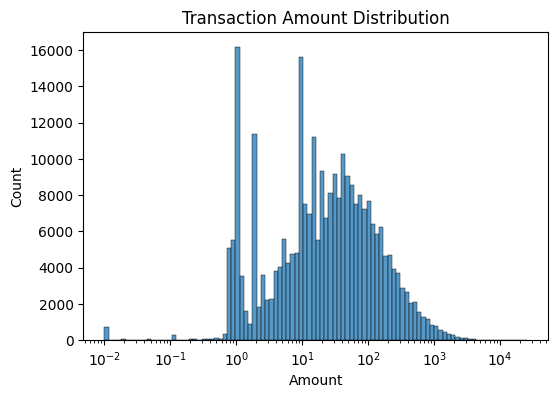

In [11]:
plt.figure(figsize=(6,4))
sns.histplot(df["Amount"], bins=100, log_scale=True)
plt.title("Transaction Amount Distribution")
plt.show()


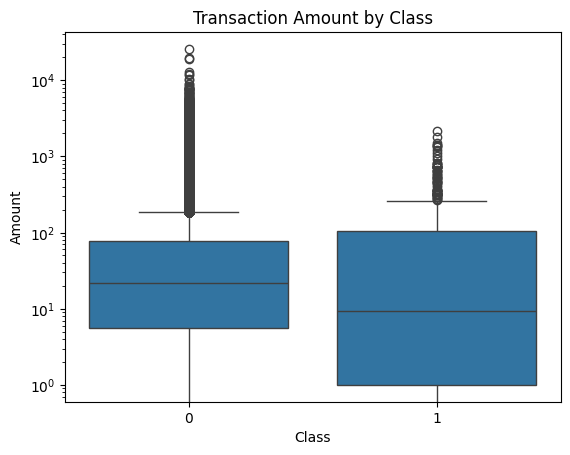

In [12]:
sns.boxplot(x=TARGET, y="Amount", data=df)
plt.title("Transaction Amount by Class")
plt.yscale("log")
plt.show()


In [13]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_normal = X[y == 0]
X_fraud = X[y == 1]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [15]:
iso_forest = IsolationForest(
    n_estimators=300,
    contamination=0.0017,  # known fraud rate
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_train_scaled)


,n_estimators,300
,max_samples,'auto'
,contamination,0.0017
,max_features,1.0
,bootstrap,False
,n_jobs,-1
,random_state,42
,verbose,0
,warm_start,False


In [20]:
iso_preds = iso_forest.predict(X_test_scaled)
iso_preds = np.where(iso_preds == -1, 1, 0)  # 1 = anomaly
values, counts = np.unique(iso_preds, return_counts=True)

# Combine them into a dictionary for easy reading
frequencies = dict(zip(values, counts))
print(frequencies)
# Output: {1: 1, 2: 2, 3: 3, 4: 4}

{np.int64(0): np.int64(56862), np.int64(1): np.int64(100)}


In [19]:
iso_preds.shape

(56962,)

In [21]:
iso_roc_auc = roc_auc_score(y_test, iso_preds)
iso_roc_auc


0.6422240533804968

In [22]:
print(classification_report(y_test, iso_preds))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.28      0.29      0.28        98

    accuracy                           1.00     56962
   macro avg       0.64      0.64      0.64     56962
weighted avg       1.00      1.00      1.00     56962



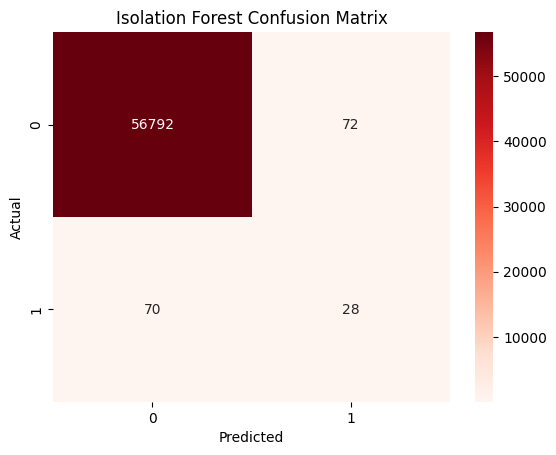

In [23]:
cm = confusion_matrix(y_test, iso_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds")
plt.title("Isolation Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Model 2 — Autoencoder (Keras)

In [24]:
X_train_normal = X_train_scaled[y_train == 0]


In [25]:
input_dim = X_train_normal.shape[1]

autoencoder = keras.Sequential([
    layers.Dense(32, activation="relu", input_shape=(input_dim,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(input_dim)
])

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-02-04 11:39:25.356468: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 30)             │           990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,334 (13.02 KB)

 Trainable params: 3,334 (13.02 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
history = autoencoder.fit(
    X_train_normal,
    X_train_normal,
    epochs=40,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)


2026-02-04 11:39:50.349489: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 24564600 exceeds 10% of free system memory.


Epoch 1/40
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.7052 - val_loss: 0.5539
Epoch 2/40
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5318 - val_loss: 0.4769
Epoch 3/40
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4717 - val_loss: 0.4368
Epoch 4/40
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4336 - val_loss: 0.4060
Epoch 5/40
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3993 - val_loss: 0.3816
Epoch 6/40
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3772 - val_loss: 0.3647
Epoch 7/40
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3644 - val_loss: 0.3537
Epoch 8/40
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3536 - val_loss: 0.3461
Epoch 9/40
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3437 - val_loss: 0.3362
Epoch 10/40
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3335 - val_loss: 0.3243
Epoch 11/40
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3269 - val_loss: 0.3154
Epoch 12/40
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

In [27]:
reconstructions = autoencoder.predict(X_test_scaled)
reconstruction_error = np.mean(np.square(X_test_scaled - reconstructions), axis=1)


1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


### Issues:
when we set the threshold using reconstructions = autoencoder.predict(X_test_scaled) reconstruction_error = np.mean(np.square(X_test_scaled - reconstructions), axis=1). should this no be done using train reconstruction and then use the threshold to predict anomaliesy. if we use 5 percentile of test, we are effectively saying we will label 5 percent of the hishest error data as fraud each time, but the population fraud might not be 5 percent

In [28]:
threshold = np.percentile(reconstruction_error, 95)
threshold


np.float64(0.7275612678718325)

In [29]:
ae_preds = (reconstruction_error > threshold).astype(int)


In [30]:
ae_roc_auc = roc_auc_score(y_test, ae_preds)
ae_roc_auc


0.9093698678120657

In [31]:
print(classification_report(y_test, ae_preds))


              precision    recall  f1-score   support

           0       1.00      0.95      0.97     56864
           1       0.03      0.87      0.06        98

    accuracy                           0.95     56962
   macro avg       0.51      0.91      0.52     56962
weighted avg       1.00      0.95      0.97     56962



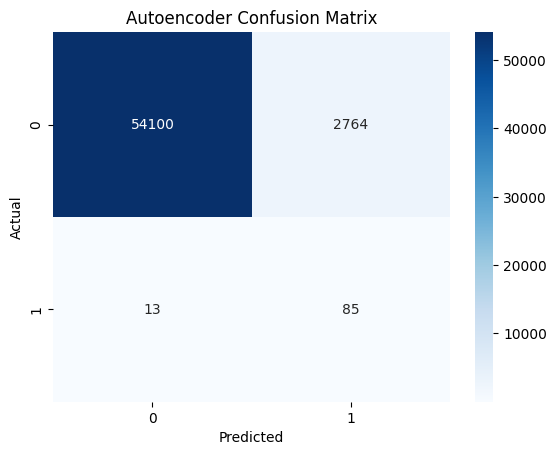

In [32]:
cm = confusion_matrix(y_test, ae_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Autoencoder Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [33]:
results = pd.DataFrame({
    "Model": ["Isolation Forest", "Autoencoder"],
    "ROC_AUC": [iso_roc_auc, ae_roc_auc]
})

results


,Model,ROC_AUC
0,Isolation Forest,0.642224
1,Autoencoder,0.909370


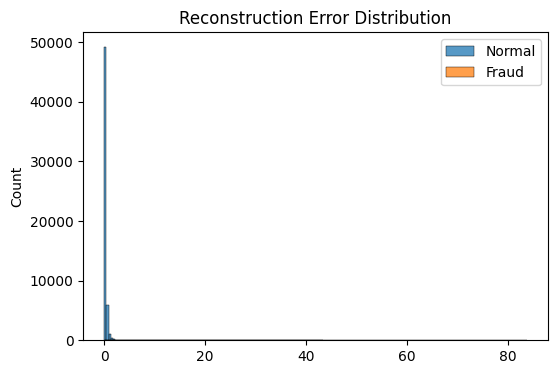

In [34]:
plt.figure(figsize=(6,4))
sns.histplot(reconstruction_error[y_test == 0], label="Normal", bins=100)
sns.histplot(reconstruction_error[y_test == 1], label="Fraud", bins=100)
plt.legend()
plt.title("Reconstruction Error Distribution")
plt.show()


### Correction

In [35]:
# Reconstruction error on TRAIN NORMAL data
train_recon = autoencoder.predict(X_train_normal)
train_recon_error = np.mean(
    np.square(X_train_normal - train_recon),
    axis=1
)

# Threshold from train distribution
threshold = np.percentile(train_recon_error, 95)


 150/7108 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step

2026-02-04 11:59:37.503673: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 27294120 exceeds 10% of free system memory.


7108/7108 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step


2026-02-04 11:59:47.720817: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 27294120 exceeds 10% of free system memory.


In [36]:
test_recon = autoencoder.predict(X_test_scaled)
test_recon_error = np.mean(
    np.square(X_test_scaled - test_recon),
    axis=1
)

ae_preds = (test_recon_error > threshold).astype(int)


1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [37]:
ae_roc_auc = roc_auc_score(y_test, ae_preds)
ae_roc_auc

0.9081564463151609

In [38]:
print(classification_report(y_test, ae_preds))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97     56864
           1       0.03      0.87      0.06        98

    accuracy                           0.95     56962
   macro avg       0.51      0.91      0.51     56962
weighted avg       1.00      0.95      0.97     56962



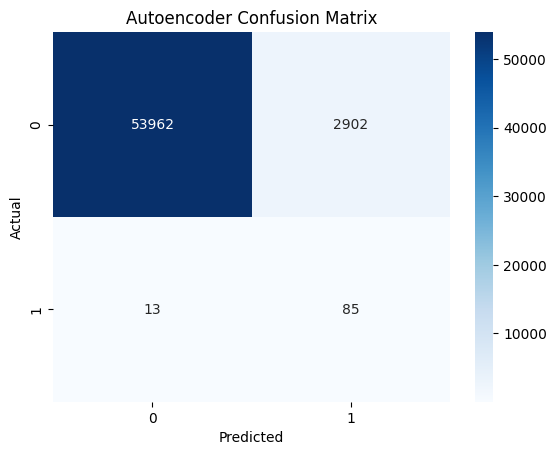

In [39]:
cm = confusion_matrix(y_test, ae_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Autoencoder Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
